In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('./Ice_cream selling data.csv')

In [5]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [45]:
df.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

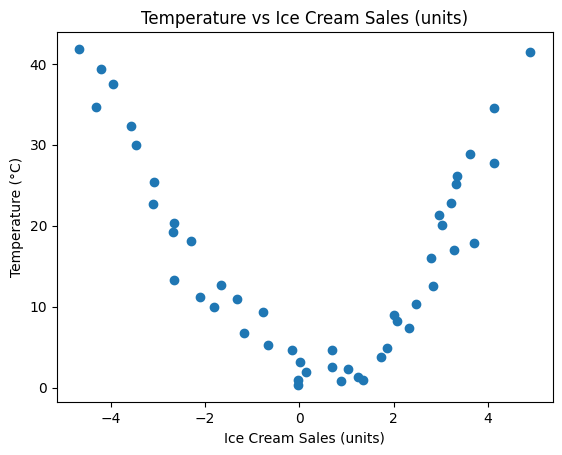

In [12]:
plt.scatter(df["Temperature (°C)"],df["Ice Cream Sales (units)"])
plt.title("Temperature vs Ice Cream Sales (units)")
plt.xlabel("Ice Cream Sales (units)")
plt.ylabel("Temperature (°C)")
plt.show()

In [101]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1:].values

In [119]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [120]:
lr = LinearRegression()

In [121]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [122]:
y_pred = lr.predict(X_test)

In [123]:
r2_score(y_test,y_pred)

-0.5751270190188227

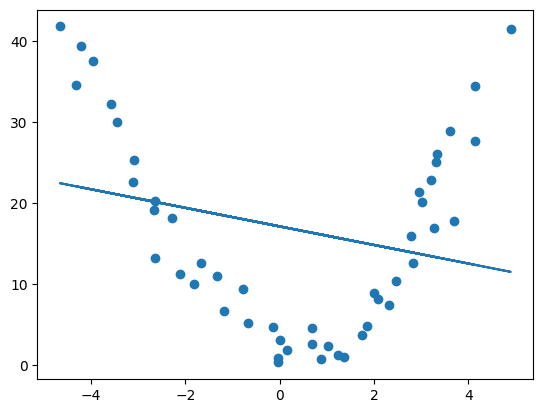

In [124]:
plt.scatter(X,y)
plt.plot(X_train,lr.predict(X_train))
plt.show()

## applying ploynomial regression 

In [125]:
from sklearn.preprocessing import PolynomialFeatures

In [164]:
ploy = PolynomialFeatures(degree=2)

In [165]:
X_train_ploy = ploy.fit_transform(X_train)
X_test_ploy = ploy.transform(X_test)

In [166]:
model = LinearRegression()

In [167]:
model.fit(X_train_ploy,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [168]:
y_pred_ploy = model.predict(X_test_ploy)

In [169]:
r2_score(y_test,y_pred_ploy)

0.843055137193884

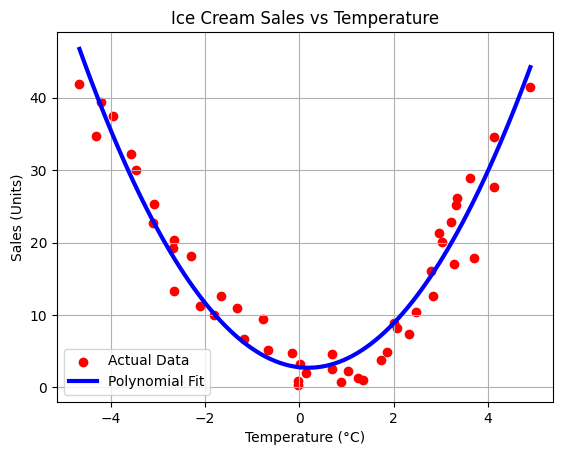

In [170]:
X_new = np.linspace(min(X), max(X), 100).reshape(-1, 1)
X_new_poly = ploy.transform(X_new)

y_new_pred = model.predict(X_new_poly)

plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X_new, y_new_pred, color='blue', linewidth=3, label='Polynomial Fit')

plt.title('Ice Cream Sales vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Sales (Units)')
plt.legend()
plt.grid(True)
plt.show()